# Feature Selection:

Now that we have analysed the data, we are ready to choose the features that will be used to train the model.

We first need to choose and preare the group of point-value metrics for the classical ML models.
Then we will need to compute the time-series features derived from the raw data like in 09.2_summarizing_group_of_gait_cycles.ipynb

Once selected, we will analyze the features in detail to choose the ones we will mvoe forward with to the next phase....


In [1]:
import core.constants as c
from core.utils import save_df_as_table_image
import os

import warnings

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

In [2]:
data = pd.read_csv(c.RICKD_FEATURE_SELECTION_DATA_FILE)
display(data.head())

data.info(verbose=True)

,id,speed_output,step_width_left,step_width_right,stride_rate_left,stride_rate_right,stride_length_left,stride_length_right,swing_time_left,swing_time_right,...,pelvic_drop_peak_vel_left,pelvic_drop_peak_vel_right,vertical_oscillation_left,vertical_oscillation_right,age,height,weight,gender,dominantleg,is_injured
0,100001_20110531T161051,2.489233,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,0.4350,0.420,...,-82.090017,-57.417845,96.433793,92.586134,47.0,172.0,61.9,female,left,True
1,100002_20110601T140505,2.722687,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,0.4450,0.420,...,-57.724685,-60.462411,86.521432,94.945518,37.0,173.4,70.6,male,left,True
2,100003_20110601T095930,2.949904,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,0.4475,0.445,...,-82.171073,-95.302664,82.680986,76.611379,51.0,186.0,86.5,male,right,True
3,100004_20110203T120721,2.688014,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,0.4400,0.460,...,-63.319119,-49.646132,92.593339,83.273183,35.0,175.6,59.0,male,left,True
4,100004_20140929T102035,2.928598,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,0.4200,0.430,...,-32.717949,-52.004473,87.481400,75.091789,39.0,175.0,61.0,male,left,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 88 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1441 non-null   object 
 1   speed_output                    1441 non-null   float64
 2   step_width_left                 1441 non-null   float64
 3   step_width_right                1441 non-null   float64
 4   stride_rate_left                1441 non-null   float64
 5   stride_rate_right               1441 non-null   float64
 6   stride_length_left              1441 non-null   float64
 7   stride_length_right             1441 non-null   float64
 8   swing_time_left                 1441 non-null   float64
 9   swing_time_right                1441 non-null   float64
 10  stance_time_left                1441 non-null   float64
 11  stance_time_right               1441 non-null   float64
 12  pelvis_peak_drop_angle_left     14

In [3]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1))/(n - 1))
    rcorr = r - ((r - 1)**2)/(n - 1)
    kcorr = k - ((k - 1)**2)/(n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data['feature'] = df.columns
    vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

# ==============================
# Main analysis function
# ==============================

def predictor_analysis(df, target, categorical_cols, numerical_cols):
    results = []
    
    y = df[target]
    y_num = LabelEncoder().fit_transform(y)
    
    for col in df.columns:
        if col == target:
            continue
                
        # Detect variable type
        if col in numerical_cols:
            # Continuous variable
            group0 = df[df[target] == y.unique()[0]][col]
            group1 = df[df[target] == y.unique()[1]][col]
            
            # t-test
            t_pval = ttest_ind(group0, group1).pvalue
            
            # Pearson
            r_val, r_pval = pearsonr(df[col], y_num)
            
            # Mutual Information
            mi_val = mutual_info_classif(df[[col]], y_num, discrete_features=False)[0]
            
            results.append({
                'predictor': col,
                'type': 'continuous',
                'Mutual Info': mi_val,
                't-test p': t_pval,
                'Pearson r': r_val,
                'Pearson p': r_pval,
            })
        
        elif col in categorical_cols:
            # Categorical variable
            contingency = pd.crosstab(df[col], y)
            chi2_pval = chi2_contingency(contingency)[1]
            mi_val = mutual_info_classif(pd.get_dummies(df[[col]]), y_num, discrete_features=True)[0]
            
            results.append({
                'predictor': col,
                'type': 'categorical',
                'Mutual Info': mi_val,
                'Chi2 p': chi2_pval,
            })
        else:
            warnings.warn(f"Column {col} missing in categorical and numerical columns, skipping!")
    
    results_df = pd.DataFrame(results)
    
    # VIF for continuous predictors
    if numerical_cols:
        vif_df = calculate_vif(df[numerical_cols].fillna(0))
    else:
        vif_df = pd.DataFrame(columns=['feature', 'VIF'])
    
    return results_df.sort_values('Mutual Info', ascending=False), vif_df.sort_values('VIF', ascending=False)


In [4]:
categorical_cols = [
    "gender",
    "dominantleg",
    "is_injured"
]

numerical_cols = [
    "speed_output",
    "step_width_left",
    "step_width_right",
    "stride_rate_left",
    "stride_rate_right",
    "stride_length_left",
    "stride_length_right",
    "swing_time_left",
    "swing_time_right",
    "stance_time_left",
    "stance_time_right",
    "pelvis_peak_drop_angle_left",
    "pelvis_peak_drop_angle_right",
    "pelvis_drop_excursion_left",
    "pelvis_drop_excursion_right",
    "ankle_df_peak_angle_left",
    "ankle_df_peak_angle_right",
    "ankle_eve_peak_angle_left",
    "ankle_eve_peak_angle_right",
    "ankle_eve_percent_stance_left",
    "ankle_eve_percent_stance_right",
    "ankle_eve_excursion_left",
    "ankle_eve_excursion_right",
    "ankle_rot_peak_angle_left",
    "ankle_rot_peak_angle_right",
    "ankle_rot_excursion_left",
    "ankle_rot_excursion_right",
    "knee_flex_peak_angle_left",
    "knee_flex_peak_angle_right",
    "knee_add_peak_angle_left",
    "knee_add_peak_angle_right",
    "knee_add_excursion_left",
    "knee_add_excursion_right",
    "knee_abd_peak_angle_left",
    "knee_abd_peak_angle_right",
    "knee_abd_excursion_left",
    "knee_abd_excursion_right",
    "knee_rot_peak_angle_left",
    "knee_rot_peak_angle_right",
    "knee_rot_excursion_left",
    "knee_rot_excursion_right",
    "hip_ext_peak_angle_left",
    "hip_ext_peak_angle_right",
    "hip_add_peak_angle_left",
    "hip_add_peak_angle_right",
    "hip_add_excursion_left",
    "hip_add_excursion_right",
    "hip_rot_peak_angle_left",
    "hip_rot_peak_angle_right",
    "hip_rot_excursion_left",
    "hip_rot_excursion_right",
    "foot_prog_angle_left",
    "foot_prog_angle_right",
    "foot_ang_at_hs_left",
    "foot_ang_at_hs_right",
    "mhw_exc_from_to_left",
    "mhw_exc_from_to_right",
    "ankle_eve_peak_vel_left",
    "ankle_eve_peak_vel_right",
    "ankle_rot_peak_vel_left",
    "ankle_rot_peak_vel_right",
    "knee_abd_peak_vel_left",
    "knee_abd_peak_vel_right",
    "knee_add_peak_vel_left",
    "knee_add_peak_vel_right",
    "hip_abd_peak_vel_left",
    "hip_abd_peak_vel_right",
    "knee_rot_peak_vel_left",
    "knee_rot_peak_vel_right",
    "hip_rot_peak_vel_left",
    "hip_rot_peak_vel_right",
    "pronation_onset_left",
    "pronation_onset_right",
    "supination_timing_left",
    "supination_timing_right",
    "hip_add_peak_vel_left",
    "hip_add_peak_vel_right",
    "pelvic_drop_peak_vel_left",
    "pelvic_drop_peak_vel_right",
    "vertical_oscillation_left",
    "vertical_oscillation_right",
    "age",
    "height",
    "weight"
]

results_df, vif_df = predictor_analysis(data, target='is_injured', categorical_cols=categorical_cols, numerical_cols=numerical_cols)

with pd.option_context('display.max_rows', None):
    display(results_df)
    display(vif_df)

save_df_as_table_image(results_df, os.path.join(c.RICKD_RESULTS_FOLDER, 'predictor_analysis_results_step1.png'))
save_df_as_table_image(vif_df, os.path.join(c.RICKD_RESULTS_FOLDER, 'predictor_analysis_VIF_step_1.png'))

/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_49394/3486220475.py:74: UserWarning: Column id missing in categorical and numerical columns, skipping!
  warnings.warn(f"Column {col} missing in categorical and numerical columns, skipping!")
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,predictor,type,Mutual Info,t-test p,Pearson r,Pearson p,Chi2 p
27,knee_flex_peak_angle_left,continuous,0.037381,0.003420,-0.077065,0.003420,NaN
83,weight,continuous,0.026441,0.452968,0.019785,0.452968,NaN
54,foot_ang_at_hs_right,continuous,0.020574,0.092213,0.044374,0.092213,NaN
3,stride_rate_left,continuous,0.020330,0.050296,-0.051575,0.050296,NaN
75,hip_add_peak_vel_left,continuous,0.019435,0.437408,-0.020473,0.437408,NaN
65,hip_abd_peak_vel_left,continuous,0.019143,0.457283,-0.019597,0.457283,NaN
44,hip_add_peak_angle_right,continuous,0.018823,0.112754,0.041797,0.112754,NaN
34,knee_abd_peak_angle_right,continuous,0.018244,0.037244,-0.054881,0.037244,NaN
0,speed_output,continuous,0.017508,0.008327,-0.069483,0.008327,NaN
19,ankle_eve_percent_stance_left,continuous,0.017066,0.580676,0.014564,0.580676,NaN


,feature,VIF
2,step_width_right,inf
1,step_width_left,inf
6,stride_length_right,2.817044e+06
5,stride_length_left,2.815172e+06
3,stride_rate_left,2.799797e+06
4,stride_rate_right,2.798121e+06
8,swing_time_right,1.669192e+04
7,swing_time_left,1.668037e+04
0,speed_output,1.145113e+04
10,stance_time_right,8.215843e+03


In [5]:
# Print the top 10 variables for each test

# Top 10 by Mutual Info
print("Top 10 variables by Mutual Information:")
print(results_df.sort_values("Mutual Info", ascending=False)[["predictor", "Mutual Info"]].head(10))

# Top 10 by t-test p (smallest p-values, i.e., most significant)
if "t-test p" in results_df.columns:
    print("\nTop 10 variables by t-test p-value:")
    print(results_df.sort_values("t-test p", ascending=True)[["predictor", "t-test p"]].head(10))

# Top 10 by Chi2 p (smallest p-values, i.e., most significant)
if "Chi2 p" in results_df.columns:
    print("\nTop 10 variables by Chi2 p-value:")
    print(results_df.sort_values("Chi2 p", ascending=True)[["predictor", "Chi2 p"]].head(10))


Top 10 variables by Mutual Information:
                        predictor  Mutual Info
27      knee_flex_peak_angle_left     0.037381
83                         weight     0.026441
54           foot_ang_at_hs_right     0.020574
3                stride_rate_left     0.020330
75          hip_add_peak_vel_left     0.019435
65          hip_abd_peak_vel_left     0.019143
44       hip_add_peak_angle_right     0.018823
34      knee_abd_peak_angle_right     0.018244
0                    speed_output     0.017508
19  ankle_eve_percent_stance_left     0.017066

Top 10 variables by t-test p-value:
                     predictor  t-test p
9             stance_time_left  0.000065
37    knee_rot_peak_angle_left  0.000096
28  knee_flex_peak_angle_right  0.000112
47     hip_rot_peak_angle_left  0.000123
42    hip_ext_peak_angle_right  0.000721
10           stance_time_right  0.000752
27   knee_flex_peak_angle_left  0.003420
38   knee_rot_peak_angle_right  0.003771
0                 speed_output  0.008

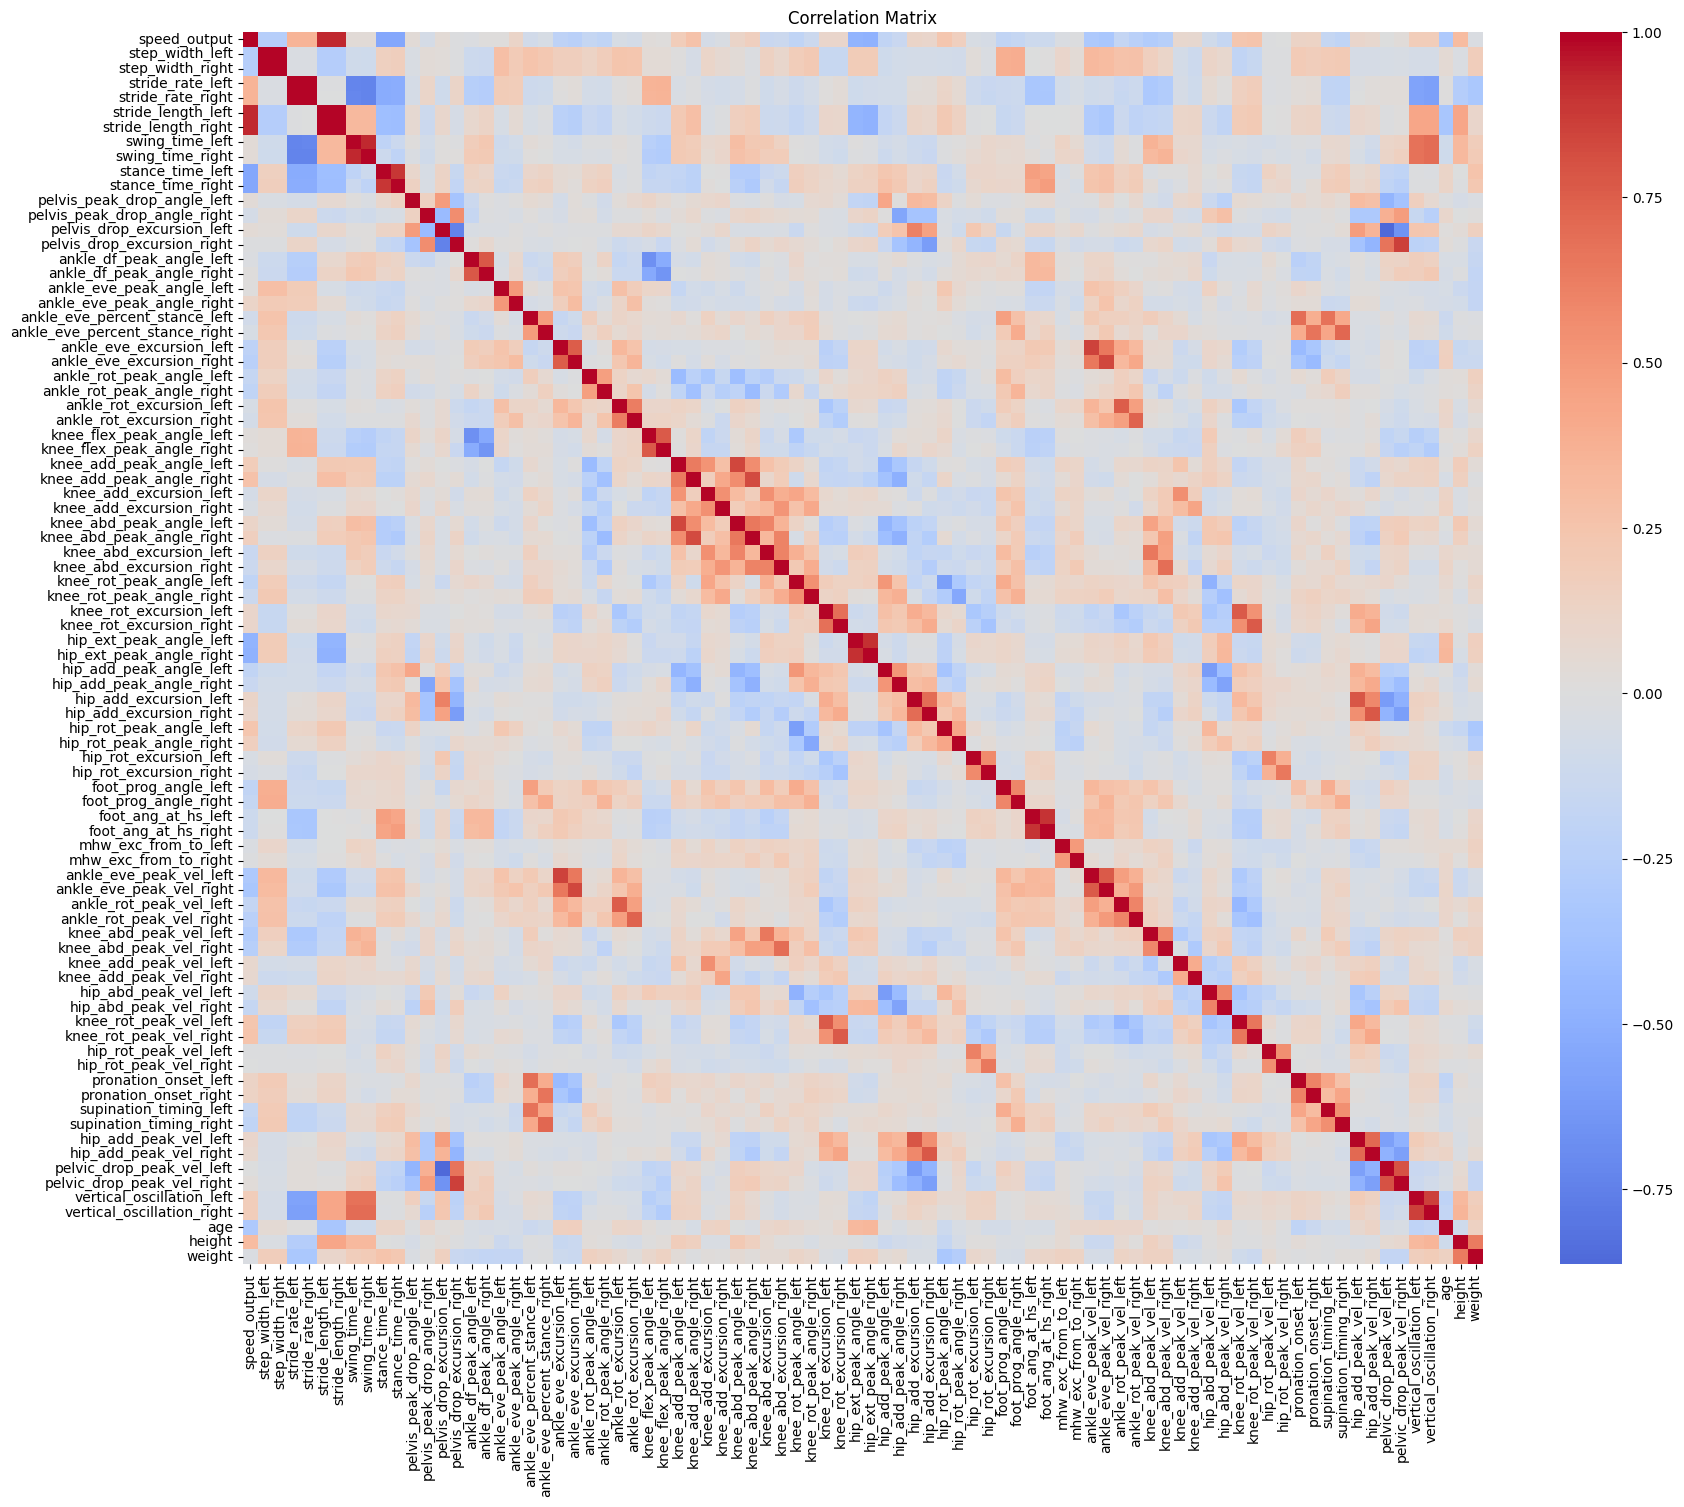

In [6]:
corr_matrix = data[numerical_cols].corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
import seaborn as sns
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


In [7]:
corr_matrix = data[numerical_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_reduced = data.drop(columns=to_drop)

print(f"Dropping {len(to_drop)} columns")
for col in to_drop:
    print(col)

df_reduced.info(verbose=True)

Dropping 7 columns
step_width_right
stride_rate_right
stride_length_left
stride_length_right
swing_time_right
hip_ext_peak_angle_right
foot_ang_at_hs_right
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 81 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1441 non-null   object 
 1   speed_output                    1441 non-null   float64
 2   step_width_left                 1441 non-null   float64
 3   stride_rate_left                1441 non-null   float64
 4   swing_time_left                 1441 non-null   float64
 5   stance_time_left                1441 non-null   float64
 6   stance_time_right               1441 non-null   float64
 7   pelvis_peak_drop_angle_left     1441 non-null   float64
 8   pelvis_peak_drop_angle_right    1441 non-null   float64
 9   pelvis_drop_excursion_left      1441 non-null   float64
 10  

In [8]:
# Rerun with the dropped columns....
reduced_categorical_cols = [
    "gender",
    "dominantleg",
    "is_injured"
]

reduced_numerical_cols = [
    "speed_output",
    "step_width_left",
    # "step_width_right",
    "stride_rate_left",
    # "stride_rate_right",
    # "stride_length_left",
    # "stride_length_right",
    "swing_time_left",
    # "swing_time_right",
    "stance_time_left",
    "stance_time_right",
    "pelvis_peak_drop_angle_left",
    "pelvis_peak_drop_angle_right",
    "pelvis_drop_excursion_left",
    "pelvis_drop_excursion_right",
    "ankle_df_peak_angle_left",
    "ankle_df_peak_angle_right",
    "ankle_eve_peak_angle_left",
    "ankle_eve_peak_angle_right",
    "ankle_eve_percent_stance_left",
    "ankle_eve_percent_stance_right",
    "ankle_eve_excursion_left",
    "ankle_eve_excursion_right",
    "ankle_rot_peak_angle_left",
    "ankle_rot_peak_angle_right",
    "ankle_rot_excursion_left",
    "ankle_rot_excursion_right",
    "knee_flex_peak_angle_left",
    "knee_flex_peak_angle_right",
    "knee_add_peak_angle_left",
    "knee_add_peak_angle_right",
    "knee_add_excursion_left",
    "knee_add_excursion_right",
    "knee_abd_peak_angle_left",
    "knee_abd_peak_angle_right",
    "knee_abd_excursion_left",
    "knee_abd_excursion_right",
    "knee_rot_peak_angle_left",
    "knee_rot_peak_angle_right",
    "knee_rot_excursion_left",
    "knee_rot_excursion_right",
    "hip_ext_peak_angle_left",
    # "hip_ext_peak_angle_right",
    "hip_add_peak_angle_left",
    "hip_add_peak_angle_right",
    "hip_add_excursion_left",
    "hip_add_excursion_right",
    "hip_rot_peak_angle_left",
    "hip_rot_peak_angle_right",
    "hip_rot_excursion_left",
    "hip_rot_excursion_right",
    "foot_prog_angle_left",
    "foot_prog_angle_right",
    "foot_ang_at_hs_left",
    #"foot_ang_at_hs_right",
    "mhw_exc_from_to_left",
    "mhw_exc_from_to_right",
    "ankle_eve_peak_vel_left",
    "ankle_eve_peak_vel_right",
    "ankle_rot_peak_vel_left",
    "ankle_rot_peak_vel_right",
    "knee_abd_peak_vel_left",
    "knee_abd_peak_vel_right",
    "knee_add_peak_vel_left",
    "knee_add_peak_vel_right",
    "hip_abd_peak_vel_left",
    "hip_abd_peak_vel_right",
    "knee_rot_peak_vel_left",
    "knee_rot_peak_vel_right",
    "hip_rot_peak_vel_left",
    "hip_rot_peak_vel_right",
    "pronation_onset_left",
    "pronation_onset_right",
    "supination_timing_left",
    "supination_timing_right",
    "hip_add_peak_vel_left",
    "hip_add_peak_vel_right",
    "pelvic_drop_peak_vel_left",
    "pelvic_drop_peak_vel_right",
    "vertical_oscillation_left",
    "vertical_oscillation_right",
    "age",
    "height",
    "weight"
]

results_df, vif_df = predictor_analysis(df_reduced, target='is_injured', categorical_cols=reduced_categorical_cols, numerical_cols=reduced_numerical_cols)

with pd.option_context('display.max_rows', None):
    display(results_df)
    display(vif_df)

# Print the top 10 variables for each test

# Top 10 by Mutual Info
print("Top 10 variables by Mutual Information:")
print(results_df.sort_values("Mutual Info", ascending=False)[["predictor", "Mutual Info"]].head(10))

# Top 10 by t-test p (smallest p-values, i.e., most significant)
if "t-test p" in results_df.columns:
    print("\nTop 10 variables by t-test p-value:")
    print(results_df.sort_values("t-test p", ascending=True)[["predictor", "t-test p"]].head(10))

# Top 10 by Chi2 p (smallest p-values, i.e., most significant)
if "Chi2 p" in results_df.columns:
    print("\nTop 10 variables by Chi2 p-value:")
    print(results_df.sort_values("Chi2 p", ascending=True)[["predictor", "Chi2 p"]].head(10))


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_49394/3486220475.py:74: UserWarning: Column id missing in categorical and numerical columns, skipping!
  warnings.warn(f"Column {col} missing in categorical and numerical columns, skipping!")


,predictor,type,Mutual Info,t-test p,Pearson r,Pearson p,Chi2 p
22,knee_flex_peak_angle_left,continuous,0.037381,0.003420,-0.077065,0.003420,NaN
65,pronation_onset_right,continuous,0.032602,0.895877,0.003451,0.895877,NaN
76,weight,continuous,0.022025,0.452968,0.019785,0.452968,NaN
68,hip_add_peak_vel_left,continuous,0.019435,0.437408,-0.020473,0.437408,NaN
58,hip_abd_peak_vel_left,continuous,0.019143,0.457283,-0.019597,0.457283,NaN
38,hip_add_peak_angle_right,continuous,0.018823,0.112754,0.041797,0.112754,NaN
29,knee_abd_peak_angle_right,continuous,0.018244,0.037244,-0.054881,0.037244,NaN
0,speed_output,continuous,0.017508,0.008327,-0.069483,0.008327,NaN
60,knee_rot_peak_vel_left,continuous,0.017031,0.978418,0.000713,0.978418,NaN
49,mhw_exc_from_to_right,continuous,0.016519,0.166802,-0.036440,0.166802,NaN


,feature,VIF
29,knee_abd_peak_angle_right,5122.469699
28,knee_abd_peak_angle_left,4870.811949
25,knee_add_peak_angle_right,1465.859207
24,knee_add_peak_angle_left,1351.316904
75,height,1050.335404
31,knee_abd_excursion_right,1022.902350
30,knee_abd_excursion_left,912.656113
5,stance_time_right,843.837912
4,stance_time_left,828.586355
3,swing_time_left,471.843133


Top 10 variables by Mutual Information:
                    predictor  Mutual Info
22  knee_flex_peak_angle_left     0.037381
65      pronation_onset_right     0.032602
76                     weight     0.022025
68      hip_add_peak_vel_left     0.019435
58      hip_abd_peak_vel_left     0.019143
38   hip_add_peak_angle_right     0.018823
29  knee_abd_peak_angle_right     0.018244
0                speed_output     0.017508
60     knee_rot_peak_vel_left     0.017031
49      mhw_exc_from_to_right     0.016519

Top 10 variables by t-test p-value:
                     predictor  t-test p
4             stance_time_left  0.000065
32    knee_rot_peak_angle_left  0.000096
23  knee_flex_peak_angle_right  0.000112
41     hip_rot_peak_angle_left  0.000123
5            stance_time_right  0.000752
22   knee_flex_peak_angle_left  0.003420
33   knee_rot_peak_angle_right  0.003771
0                 speed_output  0.008327
37     hip_add_peak_angle_left  0.010338
36     hip_ext_peak_angle_left  0.013372

## Check for correlation between sides.

In [9]:
def print_high_correlations(data: pd.DataFrame, threshold: float = 0.6):
    """
    Print features with absolute correlation above the given threshold.

    Args:
        corr_matrix (pd.DataFrame): Correlation matrix.
        threshold (float): Absolute correlation threshold.
    """
    cm = data.corr()

    metric = cm.abs().fillna(0)
    np.fill_diagonal(metric.values, 0)

    top_corr_by_col = {}
    for col in metric.columns:
        s = metric[col][metric[col] > threshold].sort_values(ascending=False)
        if not s.empty:
            signed = cm.loc[s.index, col]
            top_corr_by_col[col] = signed.reindex(s.index).round(3)

    for col, s in top_corr_by_col.items():
        print(f"{col}:")
        for feat, val in s.items():
            print(f"  {feat}: {val:+.3f}")
        print()

print_high_correlations(corr_matrix, threshold=0.6)

speed_output:
  stride_length_right: +0.879
  stride_length_left: +0.879
  hip_ext_peak_angle_right: +0.630
  hip_ext_peak_angle_left: +0.621

step_width_left:
  step_width_right: +1.000

step_width_right:
  step_width_left: +1.000

stride_rate_left:
  stride_rate_right: +1.000
  swing_time_left: +0.786
  swing_time_right: +0.784
  vertical_oscillation_right: +0.659
  vertical_oscillation_left: +0.638

stride_rate_right:
  stride_rate_left: +1.000
  swing_time_left: +0.785
  swing_time_right: +0.782
  vertical_oscillation_right: +0.657
  vertical_oscillation_left: +0.636

stride_length_left:
  stride_length_right: +1.000
  speed_output: +0.879
  hip_ext_peak_angle_right: +0.634
  hip_ext_peak_angle_left: +0.606

stride_length_right:
  stride_length_left: +1.000
  speed_output: +0.879
  hip_ext_peak_angle_right: +0.634
  hip_ext_peak_angle_left: +0.606

swing_time_left:
  swing_time_right: +0.992
  vertical_oscillation_right: +0.852
  vertical_oscillation_left: +0.835
  stride_rate_left

To reduce collinearity we will do the following:
- Drop speed in favour of stride length
- Looking at the dominant leg, extract all metrics for the dominant leg, drop the other and extract the difference between the two as a new metric.


In [10]:
data_reduced_2 = data.drop(labels=["speed_output"], axis=1)
data_reduced_2

,id,step_width_left,step_width_right,stride_rate_left,stride_rate_right,stride_length_left,stride_length_right,swing_time_left,swing_time_right,stance_time_left,...,pelvic_drop_peak_vel_left,pelvic_drop_peak_vel_right,vertical_oscillation_left,vertical_oscillation_right,age,height,weight,gender,dominantleg,is_injured
0,100001_20110531T161051,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,0.4350,0.4200,0.320,...,-82.090017,-57.417845,96.433793,92.586134,47.0,172.0,61.9,female,left,True
1,100002_20110601T140505,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,0.4450,0.4200,0.290,...,-57.724685,-60.462411,86.521432,94.945518,37.0,173.4,70.6,male,left,True
2,100003_20110601T095930,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,0.4475,0.4450,0.315,...,-82.171073,-95.302664,82.680986,76.611379,51.0,186.0,86.5,male,right,True
3,100004_20110203T120721,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,0.4400,0.4600,0.290,...,-63.319119,-49.646132,92.593339,83.273183,35.0,175.6,59.0,male,left,True
4,100004_20140929T102035,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,0.4200,0.4300,0.300,...,-32.717949,-52.004473,87.481400,75.091789,39.0,175.0,61.0,male,left,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,201100_20150409T155915,0.108809,0.108809,76.433121,76.433121,2.190908,2.190908,0.4600,0.4650,0.330,...,-146.535658,-120.697186,74.753470,86.710600,52.0,170.0,80.0,male,right,True
1437,201101_20150413T143152,0.090986,0.090986,88.235294,88.235294,1.923449,1.923449,0.4075,0.4100,0.275,...,-56.000594,-79.974041,76.066245,67.343927,21.0,162.0,65.5,male,right,False
1438,201223_20140415T132359,0.157843,0.157843,80.000000,80.536913,2.157667,2.143282,0.4925,0.3875,0.255,...,-97.270798,-161.618698,109.127002,90.804104,29.0,171.0,72.0,male,left,False
1439,201224_20140417T141711,0.071881,0.071881,78.431373,78.947368,2.235128,2.220519,0.4600,0.4650,0.300,...,-160.743124,-153.188247,114.711973,119.143577,40.0,179.0,80.0,male,right,True


In [11]:
left_suffix = "_left"
right_suffix = "_right"


df_out = data_reduced_2.copy()

left_cols = [c for c in df_out.columns if c.endswith(left_suffix)]
right_cols = [c for c in df_out.columns if c.endswith(right_suffix)]

other_cols = [c for c in df_out.columns if not c.endswith(left_suffix) and not c.endswith(right_suffix)]
if len(other_cols) > 0:
    for col in other_cols:
        print(f"Column {col} is not a left or right column")

left_suffixes = {c[:-len(left_suffix)]: c for c in left_cols}
right_suffixes = {c[:-len(right_suffix)]: c for c in right_cols}
paired_suffixes = sorted(set(left_suffixes.keys()).intersection(right_suffixes.keys()))

# Build dominance mask from 'dominantleg' column
# Treat 'ambidextrous' as right-dominant
_dominantleg = df_out["dominantleg"].astype(str).str.lower()
left_dom_arr = _dominantleg.map({"left": True, "right": False, "ambidextrous": False}).fillna(False).values

# Compute dominant and difference per metric
def compute_dominant_and_diff(left_series: pd.Series, right_series: pd.Series) -> tuple[pd.Series, pd.Series]:
    left_vals = left_series.values
    right_vals = right_series.values

    dom_vals = np.where(left_dom_arr, left_vals, right_vals)
    other_vals = np.where(left_dom_arr, right_vals, left_vals)
    diff_vals = dom_vals - other_vals

    return pd.Series(dom_vals, index=left_series.index), pd.Series(diff_vals, index=left_series.index)

# Derive features for each paired metric
new_cols = {}
for suffix in paired_suffixes:
    l_col = left_suffixes[suffix]
    r_col = right_suffixes[suffix]
    dom_series, diff_series = compute_dominant_and_diff(df_out[l_col], df_out[r_col])
    new_cols[f"dom_leg_{suffix}"] = dom_series
    new_cols[f"dom_leg_diff_{suffix}"] = diff_series

for new_name, series in new_cols.items():
    df_out[new_name] = series

# dom_leg_diff_step_width is all 0...
cols_to_drop = left_cols + right_cols + ["dominantleg", "dom_leg_diff_step_width"]

data_reduced_3 = df_out.drop(columns=cols_to_drop, errors="ignore")


data_reduced_3.info()

Column id is not a left or right column
Column age is not a left or right column
Column height is not a left or right column
Column weight is not a left or right column
Column gender is not a left or right column
Column dominantleg is not a left or right column
Column is_injured is not a left or right column
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 85 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     1441 non-null   object 
 1   age                                    1441 non-null   float64
 2   height                                 1441 non-null   float64
 3   weight                                 1441 non-null   float64
 4   gender                                 1441 non-null   object 
 5   is_injured                             1441 non-null   bool   
 6   dom_leg_ankle_df_peak_angle       

In [12]:
print_high_correlations(data_reduced_3.drop(columns=["is_injured", "id", "gender"]), threshold=0.7)

dom_leg_ankle_eve_excursion:
  dom_leg_ankle_eve_peak_vel: +0.836

dom_leg_diff_ankle_eve_excursion:
  dom_leg_diff_ankle_eve_peak_vel: +0.809

dom_leg_ankle_eve_peak_vel:
  dom_leg_ankle_eve_excursion: +0.836

dom_leg_diff_ankle_eve_peak_vel:
  dom_leg_diff_ankle_eve_excursion: +0.809

dom_leg_ankle_eve_percent_stance:
  dom_leg_supination_timing: +0.701

dom_leg_ankle_rot_excursion:
  dom_leg_ankle_rot_peak_vel: +0.733

dom_leg_diff_ankle_rot_excursion:
  dom_leg_diff_ankle_rot_peak_vel: +0.713

dom_leg_ankle_rot_peak_vel:
  dom_leg_ankle_rot_excursion: +0.733

dom_leg_diff_ankle_rot_peak_vel:
  dom_leg_diff_ankle_rot_excursion: +0.713

dom_leg_hip_add_excursion:
  dom_leg_hip_add_peak_vel: +0.789

dom_leg_diff_hip_add_excursion:
  dom_leg_diff_hip_add_peak_vel: +0.723

dom_leg_hip_add_peak_vel:
  dom_leg_hip_add_excursion: +0.789

dom_leg_diff_hip_add_peak_vel:
  dom_leg_diff_hip_add_excursion: +0.723

dom_leg_knee_abd_peak_angle:
  dom_leg_knee_add_peak_angle: +0.828

dom_leg_diff_

In [13]:
categorical_cols = [
    "id",
    "gender",
    "is_injured"
]
numerical_cols = [ c for c in data_reduced_3.columns if c not in categorical_cols]
results_df, vif_df = predictor_analysis(data_reduced_3, target='is_injured', categorical_cols=categorical_cols, numerical_cols=numerical_cols)

with pd.option_context('display.max_rows', None):
    display(results_df)
    display(vif_df)

# Print the top 10 variables for each test

# Top 10 by Mutual Info
print("Top 10 variables by Mutual Information:")
print(results_df.sort_values("Mutual Info", ascending=False)[["predictor", "Mutual Info"]].head(10))

# Top 10 by t-test p (smallest p-values, i.e., most significant)
if "t-test p" in results_df.columns:
    print("\nTop 10 variables by t-test p-value:")
    print(results_df.sort_values("t-test p", ascending=True)[["predictor", "t-test p"]].head(10))

# Top 10 by Chi2 p (smallest p-values, i.e., most significant)
if "Chi2 p" in results_df.columns:
    print("\nTop 10 variables by Chi2 p-value:")
    print(results_df.sort_values("Chi2 p", ascending=True)[["predictor", "Chi2 p"]].head(10))

,predictor,type,Mutual Info,Chi2 p,t-test p,Pearson r,Pearson p
3,weight,continuous,0.020648,NaN,0.452968,0.019785,0.452968
72,dom_leg_diff_stance_time,continuous,0.019913,NaN,0.992699,0.000241,0.992699
77,dom_leg_diff_stride_rate,continuous,0.019315,NaN,0.498406,0.017848,0.498406
57,dom_leg_knee_rot_peak_angle,continuous,0.018575,NaN,0.001763,0.082321,0.001763
76,dom_leg_stride_rate,continuous,0.017407,NaN,0.053374,-0.050903,0.053374
42,dom_leg_diff_knee_abd_excursion,continuous,0.016208,NaN,0.214895,0.032691,0.214895
63,dom_leg_pelvic_drop_peak_vel,continuous,0.015694,NaN,0.015259,-0.063903,0.015259
21,dom_leg_foot_ang_at_hs,continuous,0.015397,NaN,0.089102,0.044804,0.089102
23,dom_leg_foot_prog_angle,continuous,0.015036,NaN,0.488387,0.018267,0.488387
19,dom_leg_ankle_rot_peak_vel,continuous,0.014810,NaN,0.571523,0.014917,0.571523


,feature,VIF
41,dom_leg_knee_abd_peak_angle,10719.907333
47,dom_leg_knee_add_peak_angle,3048.869866
39,dom_leg_knee_abd_excursion,2143.176620
1,height,1041.443304
42,dom_leg_diff_knee_abd_peak_angle,703.810504
48,dom_leg_diff_knee_add_peak_angle,621.027364
45,dom_leg_knee_add_excursion,620.497410
78,dom_leg_swing_time,483.751264
74,dom_leg_stride_rate,371.219981
40,dom_leg_diff_knee_abd_excursion,325.431758


Top 10 variables by Mutual Information:
                          predictor  Mutual Info
3                            weight     0.020648
72         dom_leg_diff_stance_time     0.019913
77         dom_leg_diff_stride_rate     0.019315
57      dom_leg_knee_rot_peak_angle     0.018575
76              dom_leg_stride_rate     0.017407
42  dom_leg_diff_knee_abd_excursion     0.016208
63     dom_leg_pelvic_drop_peak_vel     0.015694
21           dom_leg_foot_ang_at_hs     0.015397
23          dom_leg_foot_prog_angle     0.015036
19       dom_leg_ankle_rot_peak_vel     0.014810

Top 10 variables by t-test p-value:
                            predictor  t-test p
71                dom_leg_stance_time  0.000227
53       dom_leg_knee_flex_peak_angle  0.000567
32      dom_leg_diff_hip_add_peak_vel  0.001458
33         dom_leg_hip_ext_peak_angle  0.001603
57        dom_leg_knee_rot_peak_angle  0.001763
64  dom_leg_diff_pelvic_drop_peak_vel  0.002541
63       dom_leg_pelvic_drop_peak_vel  0.015259


In [14]:
save_df_as_table_image(results_df, os.path.join(c.RICKD_RESULTS_FOLDER, 'predictor_analysis_results_step_2.png'))
save_df_as_table_image(vif_df, os.path.join(c.RICKD_RESULTS_FOLDER, 'predictor_analysis_VIF_step_2.png'))

In [15]:
# data_reduced_3.to_csv(c.RICKD_FEATURE_SELECTION_PART_2_DATA_FILE, index=False)